# Gala Projekts: Bank Marketing Klasifikācija

Šajā projektā mērķis ir prognozēt, vai klients pēc bankas mārketinga aktivitātēm pieslēgs termiņdepozītu.


## 1. Datu kopas iepazīšana

Vispirms ielādējam datu kopu, apskatām tās izmēru un saprotam, ko nozīmē target mainīgais `y`. Šeit `y = yes/no` nozīmē, vai klients piekrita termiņdepozītam.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_style('whitegrid')

df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()


Datu kopa: 41188 rindas, 21 kolonnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
print('Kolonnu tipi:')
print(df.info())

print('\nTarget sadalījums:')
print(df['y'].value_counts())
print(f"\nTermiņdepozīta abonēšanas īpatsvars: {(df['y'] == 'yes').mean():.1%}")


Kolonnu tipi:
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-nu

## 2. Datu sagatavošana

Tagad pārbaudām datu kvalitāti, nosakām skaitliskās un kategoriskās kolonnas un sagatavojam `X` un `y`. `y` tiek pārveidots uz `0/1`, lai modeļi ar to varētu strādāt tieši.

Šajā solī apzināti izņemam kolonnu `duration`, jo tā apraksta zvana ilgumu un pirms kontakta nav zināma. Tas padara modeli reālistiskāku bankas lietojumam.


In [3]:
print('Trūkstošās vērtības pa kolonnām:')
print(df.isnull().sum())


Trūkstošās vērtības pa kolonnām:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [4]:
y = (df['y'] == 'yes').astype(int)
X = df.drop(columns=['y', 'duration'])

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Skaitliskās kolonnas ({len(numeric_features)}): {numeric_features}")
print(f"\nKategoriskās kolonnas ({len(categorical_features)}): {categorical_features}")
print(f"\nFeatures skaits: {X.shape[1]}")
print('Kolonna duration ir izņemta, lai modelis būtu lietojams pirms kontakta.')
print('Target ir izveidots atsevišķi un nav iekļauts features.')


Skaitliskās kolonnas (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Kategoriskās kolonnas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Features skaits: 19
Kolonna duration ir izņemta, lai modelis būtu lietojams pirms kontakta.
Target ir izveidots atsevišķi un nav iekļauts features.


### Kāpēc šeit nav data leakage

Target šajā projektā ir tas, vai klients abonēs termiņdepozītu. Tāpēc target nedrīkst nonākt `features`. Tāpat visas datu transformācijas jāmāca tikai uz treniņa datiem, nevis uz visa dataset uzreiz.

Svarīgs leakage risks šajā datasetā ir kolonna `duration`, jo tā apraksta zvana ilgumu un kļūst zināma tikai pēc kontakta. Tāpēc šajā projekta versijā tā ir izņemta no `features`, lai modelis būtu godīgāks un tuvāks reālai bankas lietošanai.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print('\nTarget sadalījums treniņa kopā:')
print(y_train.value_counts(normalize=True).round(3))
print('\nTarget sadalījums testa kopā:')
print(y_test.value_counts(normalize=True).round(3))


Treniņa kopa: 32950 rindas
Testa kopa: 8238 rindas

Target sadalījums treniņa kopā:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Target sadalījums testa kopā:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


## 3. Priekšapstrāde modeļiem

Lai ar datiem varētu strādāt visi izvēlētie modeļi, kategoriskās kolonnas tiek kodētas ar `OneHotEncoder`, bet skaitliskās kolonnas tiek normalizētas ar `StandardScaler`. To saliekam vienā priekšapstrādes blokā, ko izmantosim visiem modeļiem.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Pirmais bāzes modelis — Logistic Regression

Sākam ar vienkāršu bāzes modeli, lai būtu skaidrs atskaites punkts salīdzinājumam ar stiprākiem modeļiem.


In [7]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

log_metrics = {
    'Accuracy': accuracy_score(y_test, log_pred),
    'Precision': precision_score(y_test, log_pred, zero_division=0),
    'Recall': recall_score(y_test, log_pred, zero_division=0),
    'F1': f1_score(y_test, log_pred, zero_division=0),
}

print('=== Logistic Regression rezultāti ===')
for name, value in log_metrics.items():
    print(f"{name}: {value:.3f}")

print('\nKlasifikācijas pārskats:')
print(classification_report(y_test, log_pred, digits=3))


=== Logistic Regression rezultāti ===
Accuracy: 0.901
Precision: 0.690
Recall: 0.219
F1: 0.332

Klasifikācijas pārskats:
              precision    recall  f1-score   support

           0      0.909     0.988     0.947      7310
           1      0.690     0.219     0.332       928

    accuracy                          0.901      8238
   macro avg      0.800     0.603     0.639      8238
weighted avg      0.884     0.901     0.877      8238



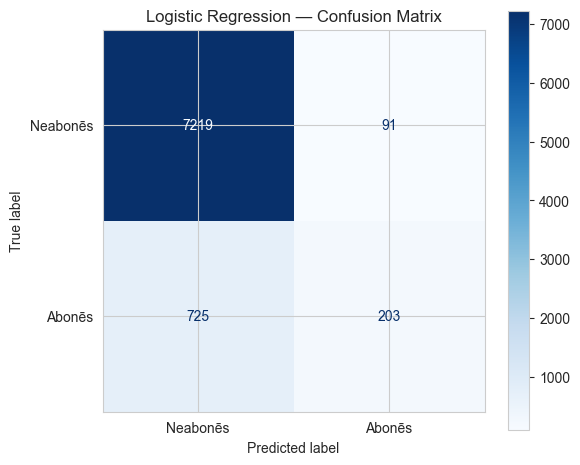

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    display_labels=['Neabonēs', 'Abonēs'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()


### Secinājums par bāzes modeli

Šis ir pirmais strādājošais modelis. Tas dod atskaites punktu, ar kuru salīdzināsim stiprākus modeļus, piemēram, kokus un ansambļa pieejas.


## 5. Divi stiprāki modeļi — Decision Tree un Random Forest

Tagad salīdzinām bāzes modeli ar koku modeļiem. Tie bieži labāk uztver sarežģītākas nelineāras sakarības datos.


In [9]:
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

def collect_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    {'Modelis': 'Logistic Regression', **log_metrics},
    {'Modelis': 'Decision Tree', **collect_metrics(y_test, tree_pred)},
    {'Modelis': 'Random Forest', **collect_metrics(y_test, rf_pred)},
]).sort_values('F1', ascending=False).reset_index(drop=True)

results.round(3)


,Modelis,Accuracy,Precision,Recall,F1
0,Decision Tree,0.903,0.685,0.249,0.365
1,Random Forest,0.902,0.708,0.220,0.336
2,Logistic Regression,0.901,0.690,0.219,0.332


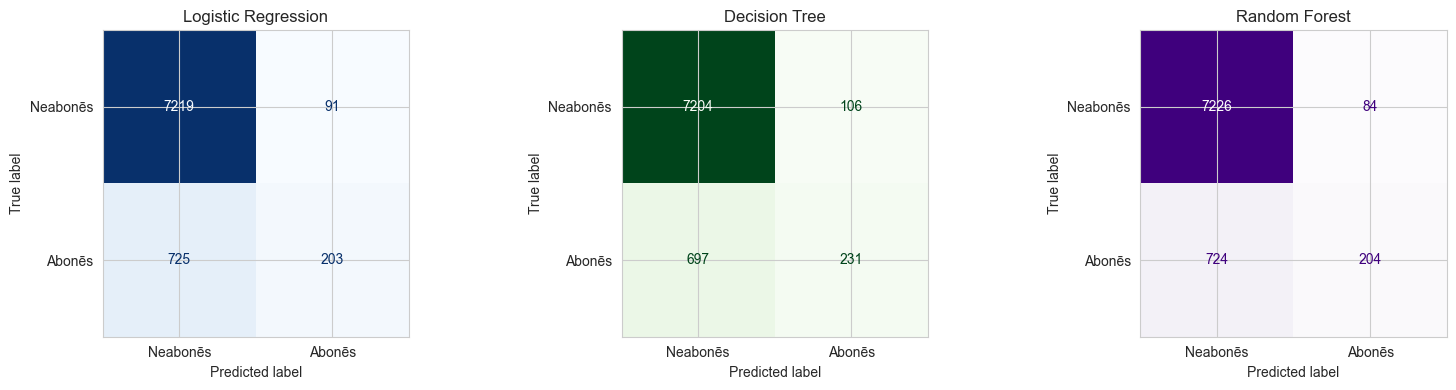

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, pred, title, cmap in [
    (axes[0], log_pred, 'Logistic Regression', 'Blues'),
    (axes[1], tree_pred, 'Decision Tree', 'Greens'),
    (axes[2], rf_pred, 'Random Forest', 'Purples'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=['Neabonēs', 'Abonēs'],
        cmap=cmap,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()


### Salīdzinājuma secinājums

Pēc viena `train/test split` labākais pamatmodelis ir `Decision Tree` ar `F1` ap `0.365`. `Random Forest` un `Logistic Regression` ir ļoti līdzīgi, bet nedaudz vājāki. Tas nozīmē, ka bez kolonnas `duration` šis uzdevums kļūst grūtāks, tomēr `Decision Tree` pagaidām ir labākais atskaites modelis tālākai validācijai.


## 6. Godīga modeļa novērtēšana — Cross-validation

Viens `train/test split` var dot nepilnīgu ainu. Tāpēc pārbaudām labāko modeli ar `5-fold cross-validation`, lai redzētu, cik stabils ir rezultāts dažādos sadalījumos.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model_name = results.loc[0, 'Modelis']
model_map = {
    'Logistic Regression': log_model,
    'Decision Tree': tree_model,
    'Random Forest': rf_model,
}
cv_model = model_map[best_model_name]
base_single_f1 = results.loc[results['Modelis'] == best_model_name, 'F1'].iloc[0]

cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='f1')
print(f"Labākais modelis pēc viena split tabulas: {best_model_name}")
print(f"\n{best_model_name} viena split F1: {base_single_f1:.3f}")
print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Labākais modelis pēc viena split tabulas: Decision Tree

Decision Tree viena split F1: 0.365
5-fold CV F1 scores: [0.329 0.37  0.409 0.372 0.35 ]
Vidējais CV F1: 0.366 ± 0.026


### Ko tas nozīmē

Šeit izmantojam `StratifiedKFold` ar sajaukšanu (`shuffle=True`), lai katrā `fold` saglabātos līdzīgs target sadalījums un rezultāts nebūtu atkarīgs no sākotnējās rindu kārtības failā. `Cross-validation` ir uzticamāka par vienu sadalījumu, jo modelis tiek testēts vairākos dažādos datu dalījumos. Standartnovirze (`std`) parāda, cik ļoti rezultāts svārstās starp dažādajiem `fold`: jo mazāka `std`, jo stabilāks modelis.


## 7. Pipeline nozīme

Lai izvairītos no `data leakage`, priekšapstrāde jāveic iekš `Pipeline`, nevis atsevišķi pirms modeļa validācijas. Šeit mūsu modeļi jau tiek trenēti ar korektu pipeline pieeju.


In [12]:
pipe_demo = make_pipeline(
    StandardScaler(with_mean=False),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

print('Pipeline piemērs ir sagatavots. Šajā projektā galvenā drošā pieeja ir ColumnTransformer + Pipeline kombinācija.')


Pipeline piemērs ir sagatavots. Šajā projektā galvenā drošā pieeja ir ColumnTransformer + Pipeline kombinācija.


### Kāpēc Pipeline ir svarīgs

Ja normalizāciju vai citu transformāciju piemēro pirms sadalīšanas, modelis netieši redz informāciju no visa dataset. Tas rada `data leakage` un var padarīt rezultātus mākslīgi labākus.


## 8. Neliela parametru uzlabošana — GridSearchCV

Tagad pārbaudām, vai `Random Forest` var nedaudz uzlabot ar mazu parametru režģi. Mērķis nav agresīva optimizācija, bet godīgs tests, vai tuning dod jēgpilnu ieguvumu.


In [13]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, 20],
}

grid_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(grid_model, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

grid_test_f1 = f1_score(y_test, grid.predict(X_test))
print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {grid_test_f1:.3f}")


Labākie parametri: {'model__max_depth': 20, 'model__n_estimators': 50}
Labākais CV F1: 0.364
Testa F1: 0.392


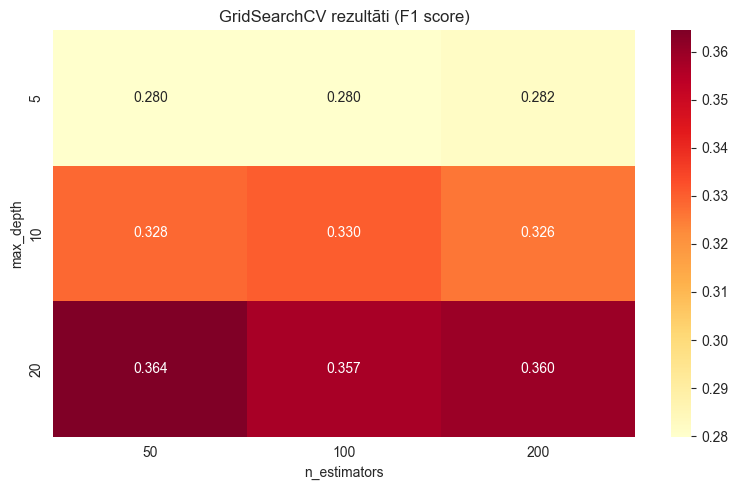

In [14]:
grid_results = pd.DataFrame(grid.cv_results_)
pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_model__max_depth',
    columns='param_model__n_estimators',
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


### Tuning secinājums

`GridSearchCV` parādīja, ka `Random Forest` var nedaudz uzlabot ar citiem parametriem. Labākā konfigurācija sasniedza `CV F1` ap `0.364`, bet testa `F1` ap `0.392`, kas ir nedaudz labāk par sākotnējo pamatmodeļu salīdzinājumu. Tātad tuning šoreiz deva nelielu, bet reālu ieguvumu, lai gan rezultāts joprojām nav ļoti augsts.


## 9. Feature importance un biznesa interpretācija

Lai rezultātu varētu izskaidrot bankai, paskatāmies, kuras pazīmes visvairāk ietekmē prognozi jau bez `duration`. Tas ir svarīgi, jo vēlamies modeli, kuru var lietot pirms zvana, nevis tikai pēc fakta. Pēc tam noformulējam biznesa secinājumus par to, kā modelis var palīdzēt mārketinga komandai.


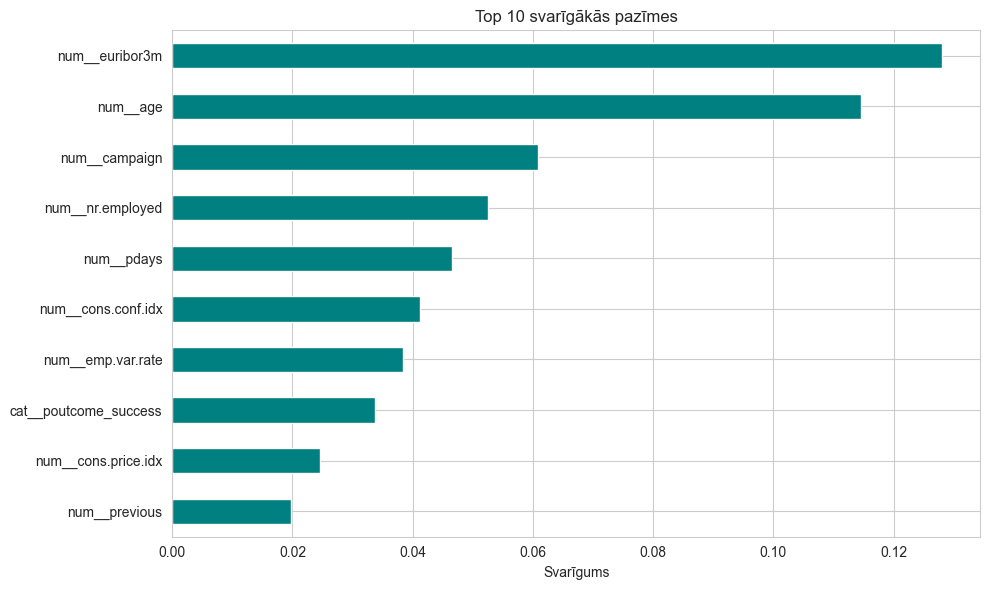

num__euribor3m           0.127962
num__age                 0.114503
num__campaign            0.060768
num__nr.employed         0.052550
num__pdays               0.046541
num__cons.conf.idx       0.041134
num__emp.var.rate        0.038449
cat__poutcome_success    0.033737
num__cons.price.idx      0.024618
num__previous            0.019746
dtype: float64

In [15]:
best_rf = grid.best_estimator_
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās pazīmes')
plt.xlabel('Svarīgums')
plt.tight_layout()
plt.show()

feat_imp.head(10)


## 10. Gala secinājums

Šajā projektā tika prognozēts, vai klients pēc bankas mārketinga kontakta abonēs termiņdepozītu. Lai modelis būtu reālistiskāks bankas lietošanai, no `features` tika izņemta kolonna `duration`, jo tā kļūst zināma tikai pēc zvana un citādi radītu leakage risku. No trim pamatmodeļiem labākais viena `train/test split` salīdzinājumā bija `Decision Tree` ar `F1` ap `0.365`, kam ļoti tuvu bija `Random Forest` un `Logistic Regression`.

Kad labāko pamatmodeli novērtējām ar `Stratified 5-fold cross-validation`, vidējais `F1` bija ap `0.366 ± 0.026`, tātad rezultāts bija samērā stabils un nebija balstīts tikai uz vienu veiksmīgu sadalījumu. `GridSearchCV` palīdzēja uzlabot `Random Forest`, un tā testa `F1` pieauga līdz ap `0.392`. Tas nozīmē, ka tuning deva nelielu ieguvumu, bet kopumā jāatzīst, ka bez pēc-zvana informācijas šī ir grūta prognozēšanas problēma.

No biznesa puses svarīgākais ir tas, ka modelis palīdz bankai atlasīt klientus ar lielāku iespēju piekrist termiņdepozītam un efektīvāk izmantot kontaktu resursus. `FP` nozīmē, ka banka velti tērē zvanu vai piedāvājumu klientam, kurš tāpat nepiekritīs. `FN` nozīmē, ka banka palaidīs garām klientu, kurš varēja abonēt produktu, tāpēc šis risks bieži ir sāpīgāks par lieku kontaktu.

Kopumā šī versija ir metodiski korektāka nekā variants ar `duration`, jo tā labāk atbilst reālajam biznesa scenārijam pirms kontakta. Tā joprojām parāda pilnu klasifikācijas plūsmu: datu saprašanu, sagatavošanu, vairāku modeļu salīdzināšanu, korektu validāciju un biznesa interpretāciju.
